In [114]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [115]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [116]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [117]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [118]:
main_path = "../GSM/solns_runs/Ex5/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [119]:
# Folders
# folders= {"n_runs_5":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_10":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_15":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_20":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list]}

folders= ["../GSM/solns_runs/Ex5/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs/Ex5/N_100/',
 '../GSM/solns_runs/Ex5/N_200/',
 '../GSM/solns_runs/Ex5/N_300/',
 '../GSM/solns_runs/Ex5/N_400/',
 '../GSM/solns_runs/Ex5/N_500/',
 '../GSM/solns_runs/Ex5/N_600/',
 '../GSM/solns_runs/Ex5/N_700/',
 '../GSM/solns_runs/Ex5/N_800/',
 '../GSM/solns_runs/Ex5/N_900/',
 '../GSM/solns_runs/Ex5/N_1000/',
 '../GSM/solns_runs/Ex5/N_1100/',
 '../GSM/solns_runs/Ex5/N_1200/',
 '../GSM/solns_runs/Ex5/N_1300/',
 '../GSM/solns_runs/Ex5/N_1400/',
 '../GSM/solns_runs/Ex5/N_1500/']

In [120]:
# folders['n_runs_5']

In [121]:
import os

def list_txt_files_in_directory(directory_path):
#     try:
#         # List all files and directories in the specified path
    files_and_directories = os.listdir(directory_path)
#     print(directory_path)
    # Filter and print only .txt files
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [122]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
# #         setX = np.random.uniform(low=0.0, high=1.0, size = num_points)
# #         setY = np.random.uniform(low=0.0, high=1.0, size = num_points)

#         t_values = np.random.uniform(0.0, 2.0, num_points)

#         points = np.column_stack((t_values, 11 - t_values, 8-t_values))

        
#         for file in files:
#             solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(len(solns)))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../GSM/solns_runs/Ex5/plot_ex5.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:

        
        t_values = np.random.uniform(0.0, 2.0, len(distinct_points))

        points = np.column_stack((t_values, 11 - t_values, 8-t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../GSM/solns_runs/Ex5/plot_ex5.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

782 1000
1537 2000
2320 3000
3055 4000
3875 5000
4587 6000
5365 7000
6198 8000
6934 9000
7672 10000
8443 11000
9160 12000
10016 13000
10683 14000
11504 15000


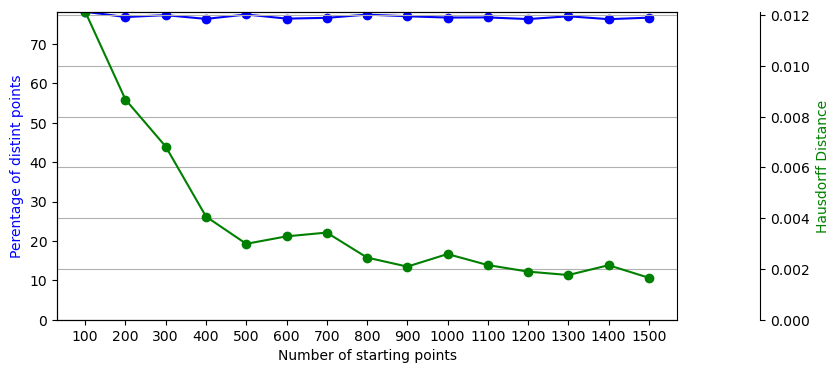

In [123]:
pdpgsm, hdgsm= get_values(folders)

In [124]:
for (p,h) in zip(pdpgsm, hdgsm):
    print(p, " * ", h)

78.2  *  0.012136934992646424
76.85  *  0.008675364051380939
77.33333333333333  *  0.006822782317851671
76.375  *  0.004064961741229893
77.5  *  0.0029908523104283644
76.44999999999999  *  0.003284900805246702
76.64285714285714  *  0.0034338528663127254
77.47500000000001  *  0.002449495293132384
77.04444444444445  *  0.0020930765037746003
76.72  *  0.002587916270675658
76.75454545454545  *  0.0021538843927171657
76.33333333333333  *  0.001896038586247938
77.04615384615384  *  0.0017610967705321487
76.30714285714286  *  0.002148018593078793
76.69333333333334  *  0.0016532344363455345


In [125]:
max(pdpgsm), min(hdgsm)

(78.2, 0.0016532344363455345)

In [126]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        fig = plt.figure(figsize=(15,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(solns[:,0], solns[:,1], solns[:,2], c= 'black', label= "Solution set")
        ax.set_xlabel(r'$x_1$')
        ax.set_ylabel(r'$x_2$')
        ax.set_zlabel(r'$x_3$')
    #     plt.legend()
#         ax.set_title("Solution set found by GSM")
        plt.show()

In [127]:
## Plot solution sets
#plot_solns(folders)

In [128]:
np.argmax(pdpgsm)

0

## Histograms

In [129]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpgsm)] #1500
print(n_points)
# Best
directory_path = "../GSM/solns_runs/Ex5/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsgsm.extend(solns.tolist())

all_solnsgsm= np.array(all_solnsgsm)

num, all_solnsgsm = count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)
print(len(all_solnsgsm))

100
782


In [130]:
all_solnsgsm

array([[ 0.44260961, 10.55739039,  7.55739039],
       [ 1.79663816,  9.20336184,  6.20336184],
       [ 1.09836908,  9.90163092,  6.90163092],
       ...,
       [ 1.53991163,  9.46008837,  6.46008837],
       [ 1.90282896,  9.09717104,  6.09717104],
       [ 0.1639221 , 10.8360779 ,  7.8360779 ]])

In [131]:
len(all_solnsgsm)
print(all_solnsgsm)

[[ 0.44260961 10.55739039  7.55739039]
 [ 1.79663816  9.20336184  6.20336184]
 [ 1.09836908  9.90163092  6.90163092]
 ...
 [ 1.53991163  9.46008837  6.46008837]
 [ 1.90282896  9.09717104  6.09717104]
 [ 0.1639221  10.8360779   7.8360779 ]]


In [132]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsgsm.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 11-x
y_min = np.min(y)
y_max = np.max(y)

## z:
z= 8-x
z_min = np.min(z)
z_max = np.max(z)

xgsm= x.copy()
ygsm= y.copy()
zgsm= z.copy()

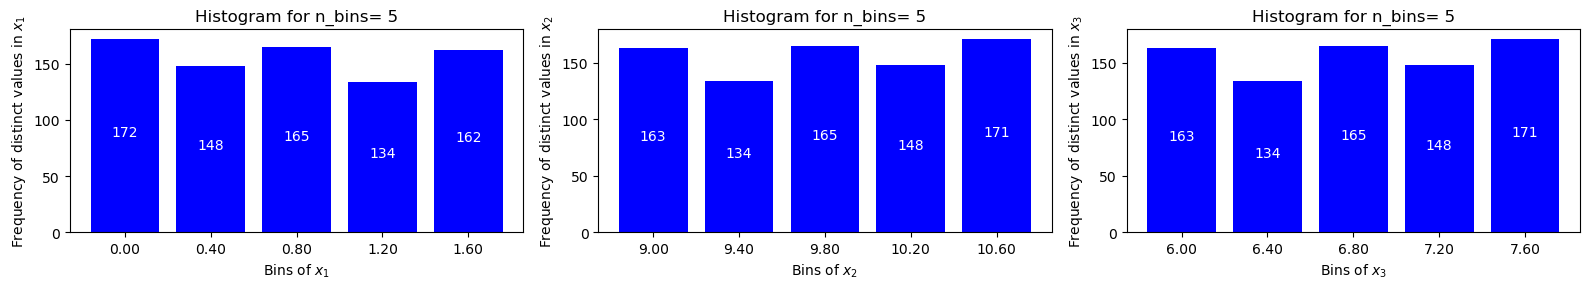

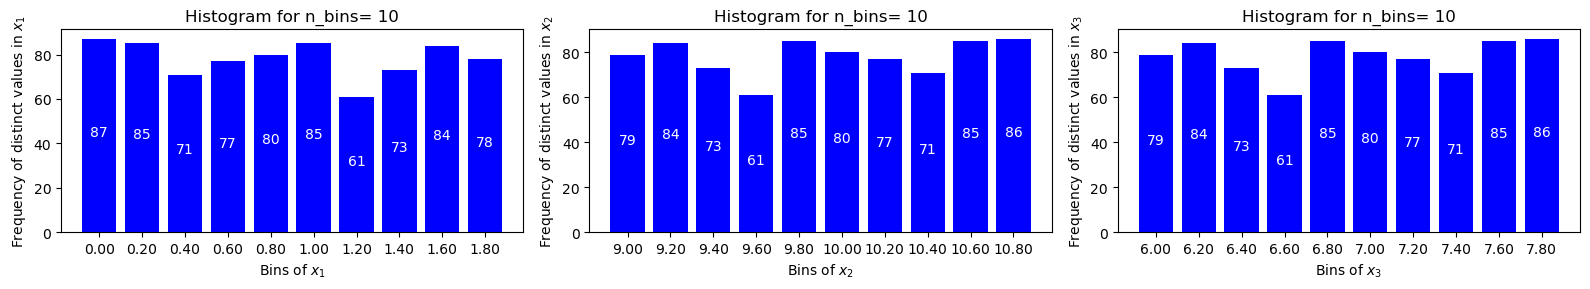

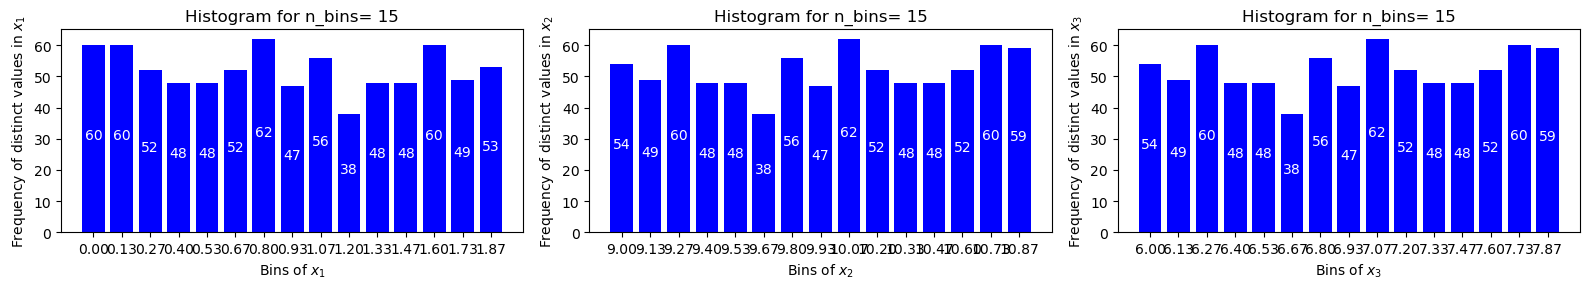

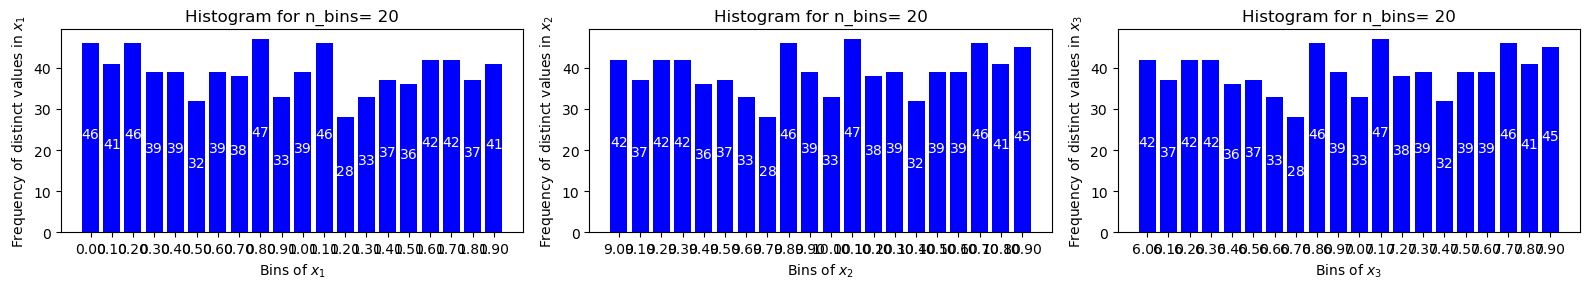

In [133]:
x_hist_gsm= []
y_hist_gsm= []

y_part_gsm= []
x_part_gsm= []

z_hist_gsm= []
z_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)


    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
    z_partition_points= partition_interval(z_min, z_max, n_bins)
    z_part_gsm.append(z_partition_points)
    z_bin_counts = count_values_in_bins(z, z_partition_points)
    z_hist_gsm.append(z_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 3, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 3, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    
    
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
    
    
    plt.subplot(1, 3, 3)
    bars = plt.bar(range(len(z_bin_counts)), z_bin_counts.values(), align='center', color='blue')
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(z_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(z_bin_counts)), ["{:.2f}".format(b) for b in z_partition_points[:-1]])
    plt.xlabel('Bins of $x_3$')
    plt.ylabel('Frequency of distinct values in $x_3$')
    plt.title('Histogram for n_bins= {}'.format(len(z_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../GSM/solns_runs/Ex5/'+'ex5_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

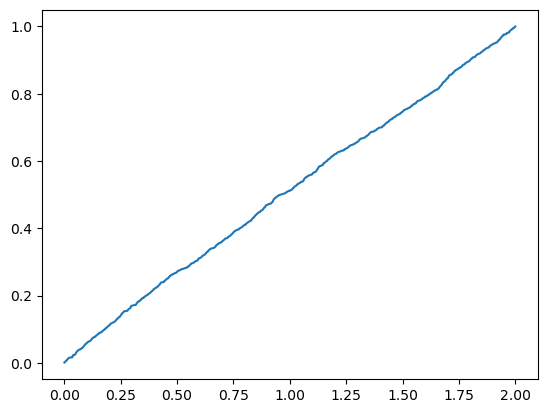

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
# fit a cdf
ecdf = ECDF(xgsm)
plt.plot(ecdf.x, ecdf.y)
plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [135]:
import numpy as np
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
data = np.random.uniform(0,1, size=100)

# Perform KS test against a normal distribution (null hypothesis)
ks_statistic, p_value = stats.kstest(data, 'norm')

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis that the data is normally distributed.")
else:
    print("Cannot reject the null hypothesis that the data is normally distributed.")


KS Statistic: 0.5018732170965315
P-value: 7.902176095057781e-24
Reject the null hypothesis that the data is normally distributed.


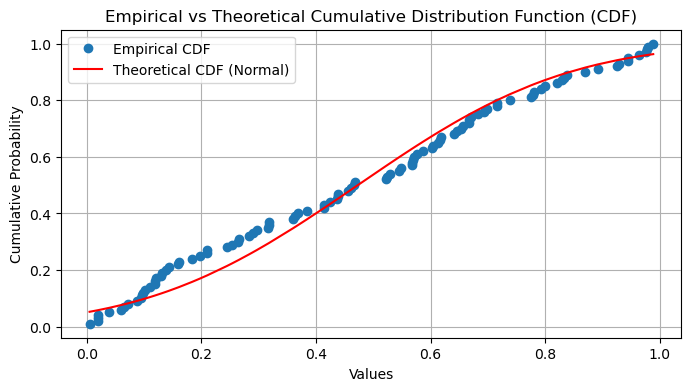

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
# data = np.random.normal(loc=0, scale=1, size=100)

# Sort the data
sorted_data = np.sort(data)

# Calculate the empirical CDF
n = sorted_data.size
y_empirical = np.arange(1, n+1) / n

# Calculate the theoretical CDF (normal distribution)
mean, std = np.mean(data), np.std(data)
y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# Plotting the empirical and theoretical CDFs
plt.figure(figsize=(8, 4))
plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
plt.xlabel('Values')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True)
plt.show()


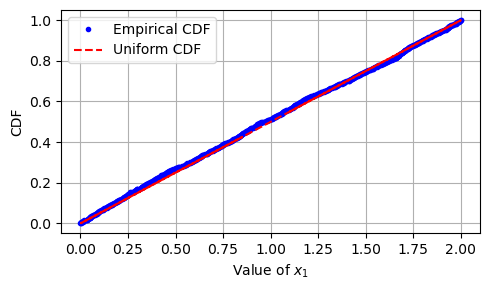

K-S Statistic: 0.4892272647085638
P-Value: 4.4740412045996536e-173
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [137]:
# KS Test on x: 
a,b= 0.0,2.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xgsm)
ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex5/ks_ex5_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [138]:
ecdf_gsm_x.y

array([0.        , 0.00127877, 0.00255754, 0.00383632, 0.00511509,
       0.00639386, 0.00767263, 0.00895141, 0.01023018, 0.01150895,
       0.01278772, 0.0140665 , 0.01534527, 0.01662404, 0.01790281,
       0.01918159, 0.02046036, 0.02173913, 0.0230179 , 0.02429668,
       0.02557545, 0.02685422, 0.02813299, 0.02941176, 0.03069054,
       0.03196931, 0.03324808, 0.03452685, 0.03580563, 0.0370844 ,
       0.03836317, 0.03964194, 0.04092072, 0.04219949, 0.04347826,
       0.04475703, 0.04603581, 0.04731458, 0.04859335, 0.04987212,
       0.0511509 , 0.05242967, 0.05370844, 0.05498721, 0.05626598,
       0.05754476, 0.05882353, 0.0601023 , 0.06138107, 0.06265985,
       0.06393862, 0.06521739, 0.06649616, 0.06777494, 0.06905371,
       0.07033248, 0.07161125, 0.07289003, 0.0741688 , 0.07544757,
       0.07672634, 0.07800512, 0.07928389, 0.08056266, 0.08184143,
       0.0831202 , 0.08439898, 0.08567775, 0.08695652, 0.08823529,
       0.08951407, 0.09079284, 0.09207161, 0.09335038, 0.09462

In [139]:
ecdf_gsm_x.x

array([          -inf, 6.58192319e-05, 3.08896609e-03, 4.66535212e-03,
       5.48706219e-03, 7.96067546e-03, 1.03955536e-02, 1.21464679e-02,
       1.28569771e-02, 1.54984354e-02, 1.67501167e-02, 1.77924617e-02,
       1.98069215e-02, 3.46040904e-02, 3.52931956e-02, 3.62478936e-02,
       3.76690129e-02, 3.83938988e-02, 3.91907736e-02, 4.70648518e-02,
       4.83718306e-02, 4.92597102e-02, 5.00275994e-02, 5.18320227e-02,
       5.25335207e-02, 5.31674300e-02, 5.51326437e-02, 5.74454499e-02,
       5.84202066e-02, 6.07217624e-02, 6.22537449e-02, 6.70550447e-02,
       7.22839460e-02, 7.34462646e-02, 7.81888577e-02, 7.89506527e-02,
       8.15103237e-02, 8.25973813e-02, 8.53611716e-02, 8.66868570e-02,
       8.79787972e-02, 8.96470476e-02, 9.06068308e-02, 9.20109313e-02,
       9.48787215e-02, 9.76418051e-02, 9.82366924e-02, 1.01178688e-01,
       1.03652444e-01, 1.04379836e-01, 1.09017263e-01, 1.14256174e-01,
       1.16233633e-01, 1.17848783e-01, 1.19736466e-01, 1.20442231e-01,
      

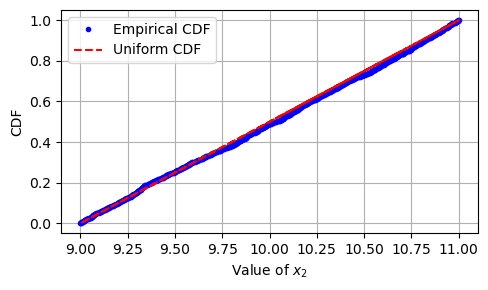

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [140]:
# KS Test on y: 
# Number of samples
a,b= 9.0, 11.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(x)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ygsm)
ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex5/ks_ex5_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ygsm, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


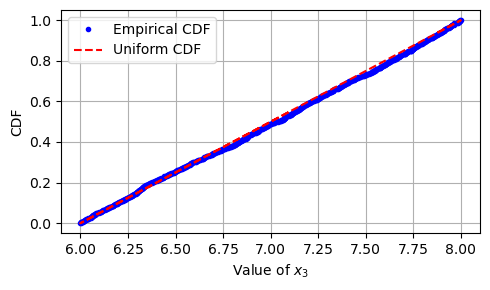

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [141]:
# KS Test on y: 
# Number of samples
a,b= 6.0, 8.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(zgsm))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(zgsm)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(zgsm)
ecdf_gsm_z = ECDF(zgsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_z.x, ecdf_gsm_z.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_3$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex5/ks_ex5_x3.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(zgsm, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


In [142]:
xgsm

array([4.42609606e-01, 1.79663816e+00, 1.09836908e+00, 1.34332011e+00,
       1.30339200e+00, 8.84280816e-01, 1.59278792e+00, 5.41222673e-01,
       1.43883263e+00, 1.02596813e+00, 1.11885898e+00, 4.01829306e-01,
       2.91185661e-01, 1.03996173e+00, 1.83654877e+00, 1.34812757e+00,
       1.67705590e-01, 1.12976649e+00, 1.67585221e+00, 7.46324333e-01,
       5.19597850e-01, 2.45730520e-01, 6.95871611e-01, 1.18155324e+00,
       3.72104977e-01, 6.46613671e-01, 9.63601979e-01, 8.29052809e-01,
       1.88764880e+00, 1.46361824e+00, 1.51240447e+00, 1.20686752e+00,
       9.19813857e-01, 1.20577102e+00, 1.28156250e+00, 1.96060030e+00,
       6.27070407e-01, 3.78205428e-01, 1.02757749e+00, 2.28469243e-01,
       4.15422837e-01, 1.45447540e-01, 8.72353605e-01, 8.59341993e-01,
       1.85037885e+00, 2.39854109e-01, 1.24068900e+00, 2.01156922e-01,
       5.74454499e-02, 8.69825176e-01, 1.36194034e+00, 1.18769791e+00,
       1.43071453e+00, 1.80966273e+00, 1.03299904e+00, 1.98723422e+00,
      

# PVI

In [143]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
number_points_list= nubmer_points_list

In [144]:
def constraint_function1(x):
    return 14-(x[0]+2*x[1]-x[2])

def constraint_function2(x):
    return 30-(3*x[0]+2*x[1]+x[2])
def constraint_function(x):
  return np.array([constraint_function1(x),constraint_function2(x)])

In [145]:
# New
## Load data

import json

# with open('../Scripts/PVI/Ex3PVI.json') as f:
#     data= json.load(f)

with open('../Scripts/PVI/Ex5PVIT.json') as f:
    dataT= json.load(f)

T_list= [1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict



for T in T_list:
    data_all= []

    for i in range(len(nubmer_points_list)):
        res_= []

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            
            for t in range(len(dataT[str(T)][i])):
                #print(data[str(i)][t])
                # if np.all(np.abs(constraint_function(dataT[str(T)][i][t]))< 1e-6):
                res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all


res_all= []

for i in range(len(nubmer_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)

In [146]:
data_all= res_all

In [147]:
data_all[0][20]

[0.008888595731711512, 10.99111140426829, 7.991111404268289]

In [148]:
data= []
dist_= []
avg_hd= []

for (idx, pt) in enumerate(nubmer_points_list):
    dt= []
    
    num_points= nubmer_points_list[idx]

    num, distinct_points = count_repeated_points(np.array(data_all[idx]))
    
    distinct_points= np.array(distinct_points)
    
    t_values = np.random.uniform(0.0, 2.0, len(distinct_points))

    points = np.column_stack((t_values, 11 - t_values, 8-t_values))
       
    
    hausdorff_distance = directed_hausdorff(np.array(data_all[idx]), points)[0]
    dist_.append((len(distinct_points)/(len(data_all[idx])))*100)
    avg_hd.append(hausdorff_distance)

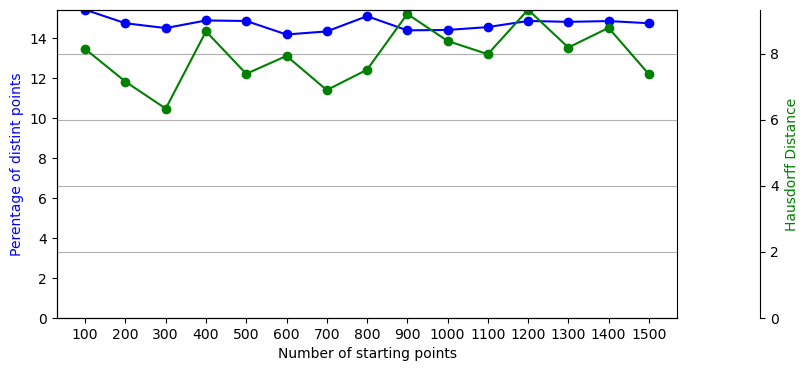

In [149]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs/Ex5/plot_ex5.png')
plt.grid(True)
plt.show()

In [150]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [151]:
hausdorff_distance
# distinct_points

7.3753284447099405

In [152]:
pdppvi

[15.430677107323815,
 14.752116082224909,
 14.511290067898312,
 14.892358646794419,
 14.866204162537166,
 14.189902034664655,
 14.343778681001703,
 15.107790578305009,
 14.397799062563685,
 14.416496714253343,
 14.560233430596082,
 14.868916737141538,
 14.822423398328691,
 14.862415021042407,
 14.754351314652512]

In [153]:
hdgpvi

[8.137216900703239,
 7.148778463874893,
 6.332469100727764,
 8.671958489157221,
 7.385861929215873,
 7.9287972787354795,
 6.893765778293439,
 7.510039430511868,
 9.198977018691247,
 8.381382950643507,
 7.98083183699257,
 9.327290041682598,
 8.182819176837661,
 8.779028448175927,
 7.3753284447099405]

In [154]:
for (p,h) in zip(pdppvi,hdgpvi):
    print(p, " *** ", h)

15.430677107323815  ***  8.137216900703239
14.752116082224909  ***  7.148778463874893
14.511290067898312  ***  6.332469100727764
14.892358646794419  ***  8.671958489157221
14.866204162537166  ***  7.385861929215873
14.189902034664655  ***  7.9287972787354795
14.343778681001703  ***  6.893765778293439
15.107790578305009  ***  7.510039430511868
14.397799062563685  ***  9.198977018691247
14.416496714253343  ***  8.381382950643507
14.560233430596082  ***  7.98083183699257
14.868916737141538  ***  9.327290041682598
14.822423398328691  ***  8.182819176837661
14.862415021042407  ***  8.779028448175927
14.754351314652512  ***  7.3753284447099405


In [155]:
max(dist_), min(avg_hd)

(15.430677107323815, 6.332469100727764)

In [156]:
# # Best npoint
# sol= np.array(data[0])
# print(sol)

In [157]:
pdppvi_all, hdgpvi_all= dist_.copy(),avg_hd.copy()

In [158]:
pdppvi_all

[15.430677107323815,
 14.752116082224909,
 14.511290067898312,
 14.892358646794419,
 14.866204162537166,
 14.189902034664655,
 14.343778681001703,
 15.107790578305009,
 14.397799062563685,
 14.416496714253343,
 14.560233430596082,
 14.868916737141538,
 14.822423398328691,
 14.862415021042407,
 14.754351314652512]

In [159]:
hdgpvi_all

[8.137216900703239,
 7.148778463874893,
 6.332469100727764,
 8.671958489157221,
 7.385861929215873,
 7.9287972787354795,
 6.893765778293439,
 7.510039430511868,
 9.198977018691247,
 8.381382950643507,
 7.98083183699257,
 9.327290041682598,
 8.182819176837661,
 8.779028448175927,
 7.3753284447099405]

In [160]:
nubmer_points_list[10:]

[1100, 1200, 1300, 1400, 1500]

In [161]:
# Ratio

In [162]:
# r= []
# for i in range(len(data_all)):
#     #total= ()/(50)
#     print(len(data_all[i]), len(data[i]), "Ratio: ", len(data[i])/len(data_all[i]))
#     r.append(len(data[i])/len(data_all[i]))

In [163]:
# r

## Histogram

In [164]:
# Best npoint
n_points= nubmer_points_list[np.argmax(pdppvi)]#1500 
# sol= np.array(data_all[14])
sol= np.array(data_all[np.argmax(pdppvi)])
print(sol)

[[9.74392416e-03 1.09902561e+01 7.99025608e+00]
 [5.98442968e-03 1.09940156e+01 7.99401557e+00]
 [1.07789825e-02 1.09892210e+01 7.98922102e+00]
 ...
 [4.66911015e-03 1.09953309e+01 7.99533089e+00]
 [5.87098635e-04 1.09994129e+01 7.99941290e+00]
 [7.95169695e-03 1.09920483e+01 7.99204830e+00]]


In [165]:
# PVI
solnspvi=  sol.copy() #np.genfromtxt("../PVI/Ex5"+"/"+"solnsEx5.txt", delimiter=',') #np.array(solns) #sol

num, distinct_points = count_repeated_points(solnspvi)
solnspvi= np.array(distinct_points)
solnspvi

array([[9.74392416e-03, 1.09902561e+01, 7.99025608e+00],
       [5.98442968e-03, 1.09940156e+01, 7.99401557e+00],
       [1.07789825e-02, 1.09892210e+01, 7.98922102e+00],
       ...,
       [4.88024003e-01, 1.05119760e+01, 7.51197600e+00],
       [3.46441253e+00, 7.53558747e+00, 4.53558747e+00],
       [2.16096233e+00, 8.83903767e+00, 5.83903767e+00]])

In [166]:
for i in range(len(solnspvi)):
    print(solnspvi[i])

[9.74392416e-03 1.09902561e+01 7.99025608e+00]
[5.98442968e-03 1.09940156e+01 7.99401557e+00]
[1.07789825e-02 1.09892210e+01 7.98922102e+00]
[ 0.01105983 10.98894017  7.98894017]
[9.32942177e-04 1.09990671e+01 7.99906706e+00]
[6.66881704e-04 1.09993331e+01 7.99933312e+00]
[6.33145690e-03 1.09936685e+01 7.99366854e+00]
[ 0.06437644 10.93562356  7.93562356]
[ 0.91515072 10.08484928  7.08484928]
[8.07348834e-03 1.09919265e+01 7.99192651e+00]
[1.21003394e-03 1.09987900e+01 7.99878997e+00]
[1.94680206 9.05319794 6.05319794]
[ 0. 11.  8.]
[ 0.84251571 10.15748429  7.15748429]
[1.86193606e-03 1.09981381e+01 7.99813806e+00]
[8.88859573e-03 1.09911114e+01 7.99111140e+00]
[2.15425023e-03 1.09978457e+01 7.99784575e+00]
[ 0.01573653 10.98426347  7.98426347]
[9.22675615e-03 1.09907732e+01 7.99077324e+00]
[4.73685484e-03 1.09952631e+01 7.99526315e+00]
[3.83016609e-03 1.09961698e+01 7.99616983e+00]
[4.30756723e-03 1.09956924e+01 7.99569243e+00]
[ 0.62260919 10.37739081  7.37739081]
[ 0.05764751 10.94

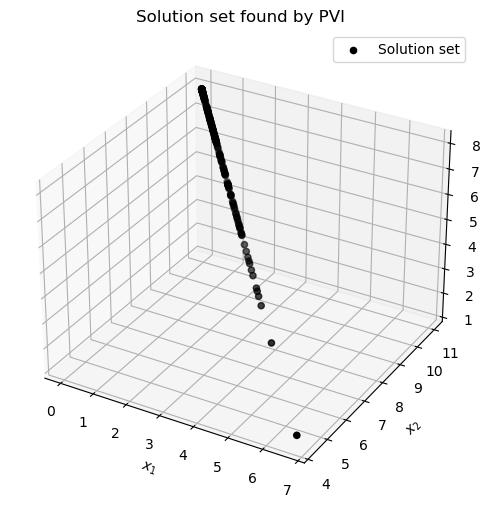

In [167]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(111, projection='3d')
# Plot the curve in 3D
ax.scatter(solnspvi[:,0], solnspvi[:,1], solnspvi[:,2], c= 'black', label= "Solution set")
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$x_3$')
plt.legend()
ax.set_title("Solution set found by PVI")
# plt.savefig('./Ex_with_no_sols/Figures/Ex2/PVI_ex2.png', dpi=180, bbox_inches='tight')
plt.show()

In [168]:
## x:
bins_list= [5, 10, 15, 20]
solns= solnspvi.copy()
x= solns[:,0]

x_min = np.min(x)
x_max = np.max(x)

## y:
y= 11-x
y_min = np.min(y)
y_max = np.max(y)

## z:
z= 8-x
z_min = np.min(z)
z_max = np.max(z)

xpvi= x.copy()
ypvi= y.copy()
zpvi= z.copy()

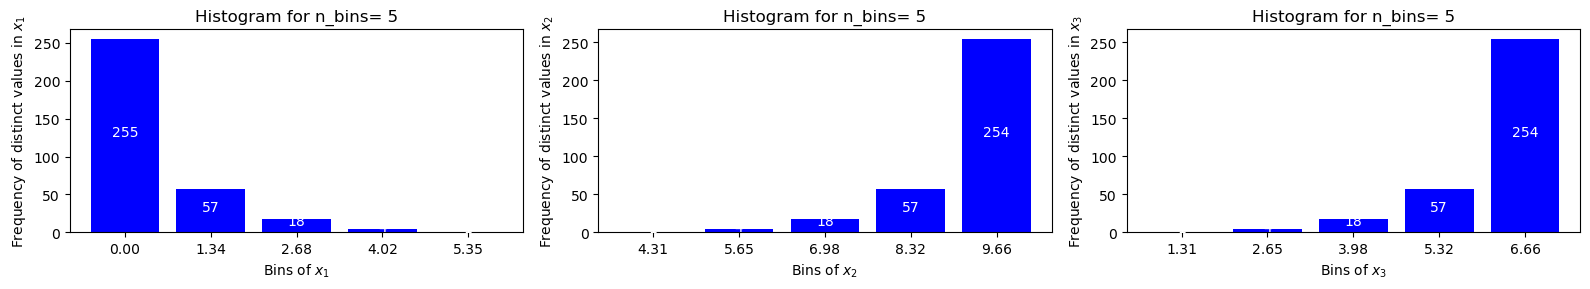

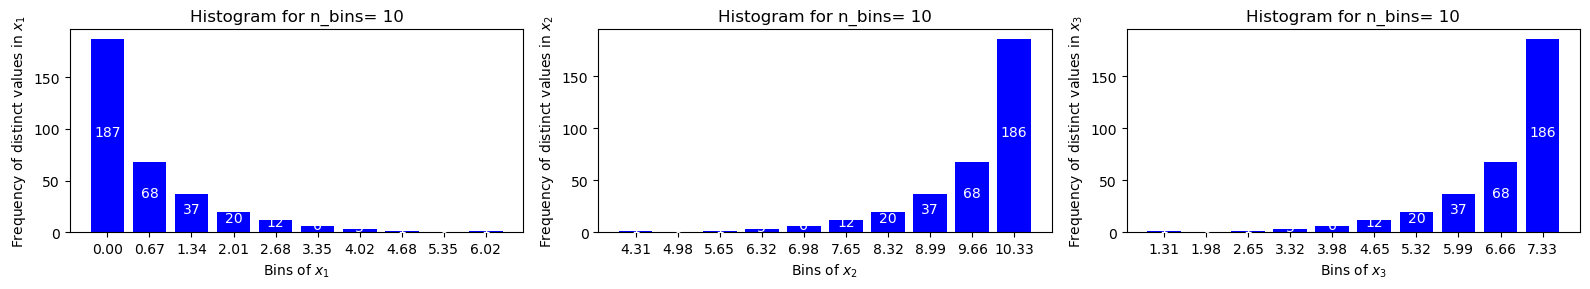

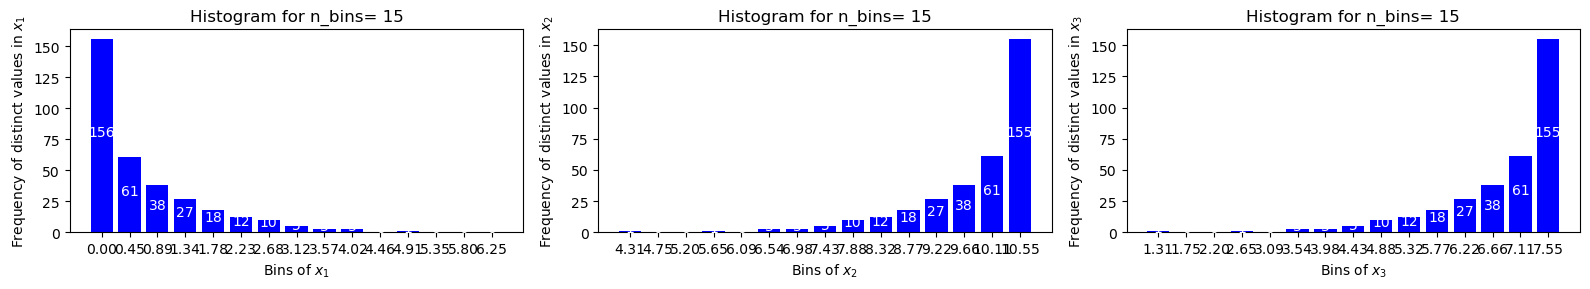

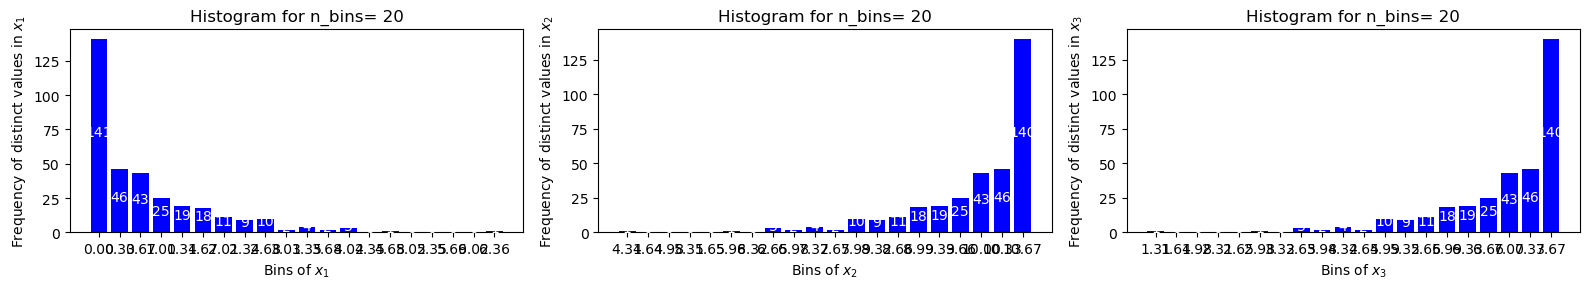

In [169]:
x_hist_pvi= []
y_hist_pvi= []

y_part_pvi= []
x_part_pvi= []

z_hist_pvi= []
z_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)


    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)
    
    z_partition_points= partition_interval(z_min, z_max, n_bins)
    z_part_pvi.append(z_partition_points)
    z_bin_counts = count_values_in_bins(z, z_partition_points)
    z_hist_pvi.append(z_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 3, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 3, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    
    
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
    
    
    plt.subplot(1, 3, 3)
    bars = plt.bar(range(len(z_bin_counts)), z_bin_counts.values(), align='center', color='blue')
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(z_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(z_bin_counts)), ["{:.2f}".format(b) for b in z_partition_points[:-1]])
    plt.xlabel('Bins of $x_3$')
    plt.ylabel('Frequency of distinct values in $x_3$')
    plt.title('Histogram for n_bins= {}'.format(len(z_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    #plt.savefig('../PVI/solns_runs/Ex5/'+'ex5_pvi_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

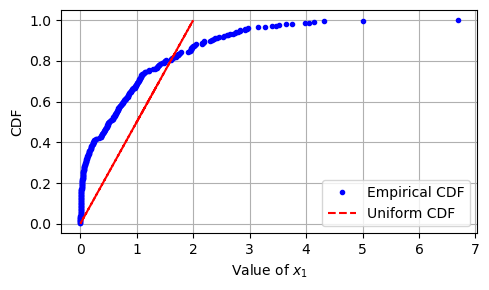

K-S Statistic: 0.3152351280746811
P-Value: 4.335063984000152e-30
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [170]:
# KS Test on x: 
a,b= 0.0,2.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xpvi)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xpvi)
ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../PVI/solns_runs/Ex5/ks_ex5_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

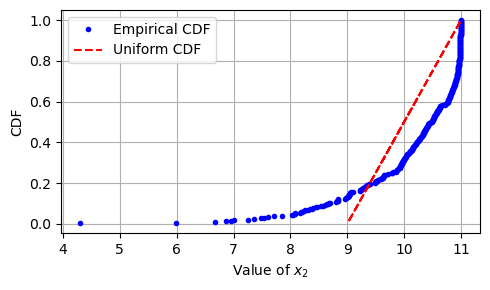

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [171]:
# KS Test on y: 
# Number of samples
a,b= 9.0, 11.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(xpvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ypvi)
ecdf_pvi_y = ECDF(ypvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_y.x, ecdf_pvi_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../PVI/solns_runs/Ex5/ks_ex5_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ypvi, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

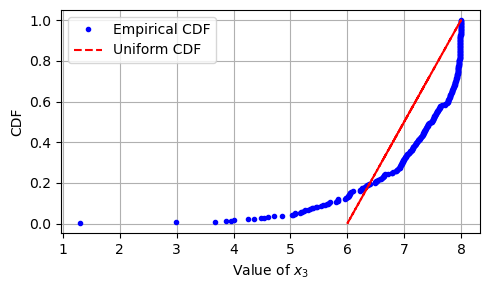

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [172]:
# KS Test on y: 
# Number of samples
a,b= 6.0, 8.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(zpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(zpvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(zpvi)
ecdf_pvi_z = ECDF(zpvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_z.x, ecdf_pvi_z.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_3$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../PVI/solns_runs/Ex5/ks_ex5_x3.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(zpvi, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


### Number of starting points vs. PDP and HD

In [173]:
# pdp, hd= get_values(folders)

In [174]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]

# BFGS

In [175]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [176]:
main_path = "../Merit/solns_runs/Ex5/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs/Ex5/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs/Ex5/N_100/',
 '../Merit/solns_runs/Ex5/N_200/',
 '../Merit/solns_runs/Ex5/N_300/',
 '../Merit/solns_runs/Ex5/N_400/',
 '../Merit/solns_runs/Ex5/N_500/',
 '../Merit/solns_runs/Ex5/N_600/',
 '../Merit/solns_runs/Ex5/N_700/',
 '../Merit/solns_runs/Ex5/N_800/',
 '../Merit/solns_runs/Ex5/N_900/',
 '../Merit/solns_runs/Ex5/N_1000/',
 '../Merit/solns_runs/Ex5/N_1100/',
 '../Merit/solns_runs/Ex5/N_1200/',
 '../Merit/solns_runs/Ex5/N_1300/',
 '../Merit/solns_runs/Ex5/N_1400/',
 '../Merit/solns_runs/Ex5/N_1500/']

In [177]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:

        
        t_values = np.random.uniform(0.0, 2.0, len(distinct_points))

        points = np.column_stack((t_values, 11 - t_values, 8-t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex5/plot_ex5.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

785 1000
1761 2000
2963 3000
3963 4000
4938 5000
5923 6000
6923 7000
7917 8000
8892 9000
9889 10000
10901 11000
10707 12000
11617 13000
13874 14000
14863 15000


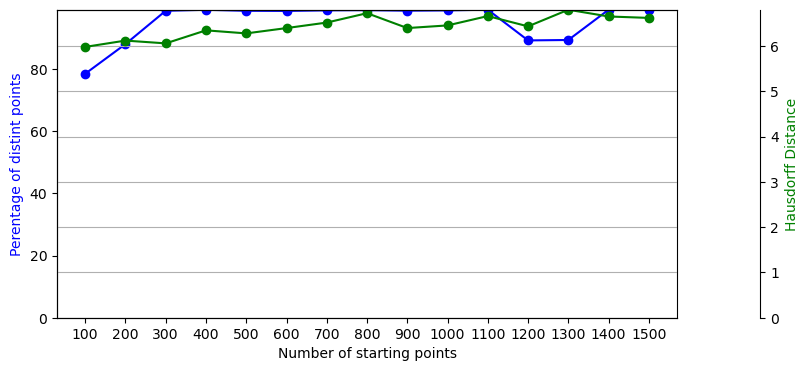

In [178]:
pdpbfgs, hdbfgs= get_values(folders)

In [179]:
for (p,h) in zip(pdpbfgs,hdbfgs):
    print(p, " * ", h)

78.5  *  5.982261934392903
88.05  *  6.121619562485943
98.76666666666667  *  6.060142064005627
99.075  *  6.348009416772916
98.76  *  6.28062589044993
98.71666666666667  *  6.39812348249242
98.9  *  6.519704713699161
98.96249999999999  *  6.726917186710633
98.8  *  6.3983826077409764
98.89  *  6.456809017915951
99.1  *  6.6633564382928805
89.225  *  6.435820391936997
89.36153846153846  *  6.803504935258942
99.1  *  6.6543613974338065
99.08666666666667  *  6.622629384218322


In [180]:
max(pdpbfgs), min(hdbfgs)

(99.1, 5.982261934392903)

In [181]:
#plot_solns(folders)

In [182]:
nubmer_points_list[np.argmax(pdpbfgs)]

1100

### Histograms

In [183]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpbfgs)] # 1500
# Best
directory_path = "../Merit/solns_runs/Ex5/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns.tolist())

all_solnsbfgs= np.array(all_solnsbfgs)

num, all_solnsbfgs = count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

In [184]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsbfgs.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 11-x
y_min = np.min(y)
y_max = np.max(y)

## z:
z= 8-x
z_min = np.min(z)
z_max = np.max(z)

xbfgs= x.copy()
ybfgs= y.copy()
zbfgs= z.copy()

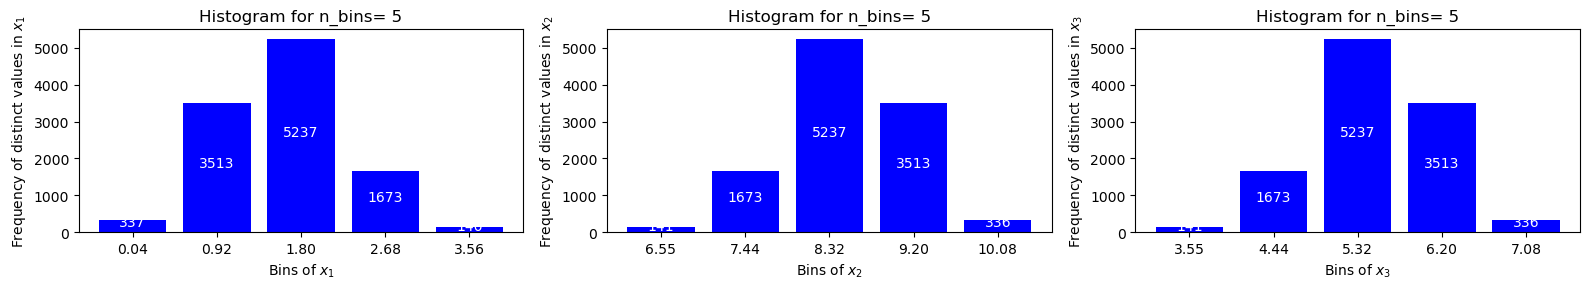

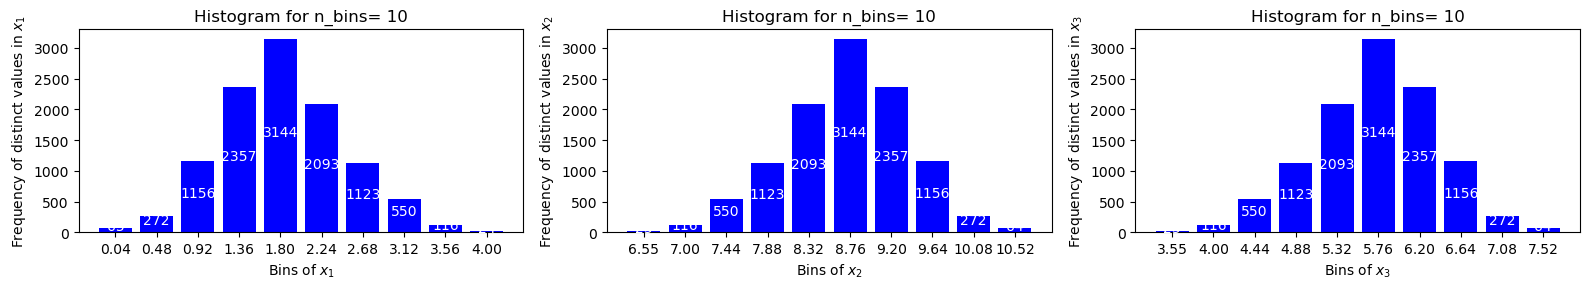

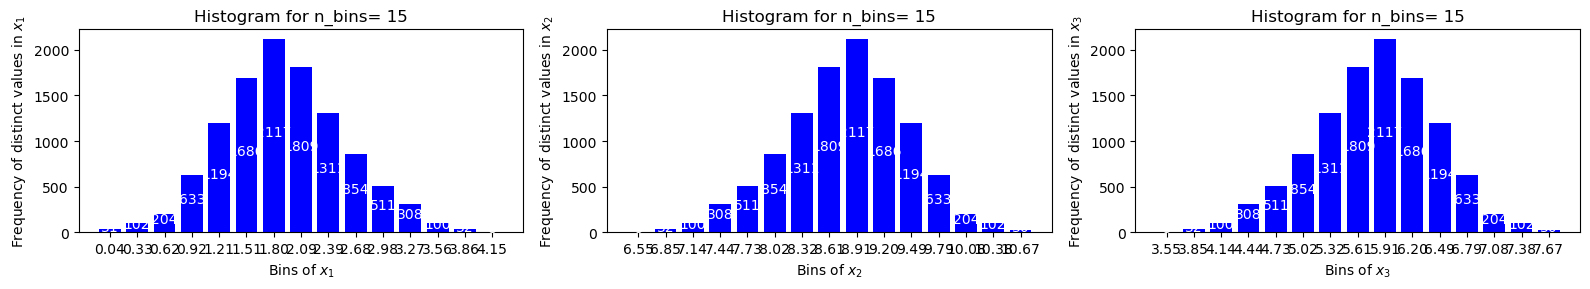

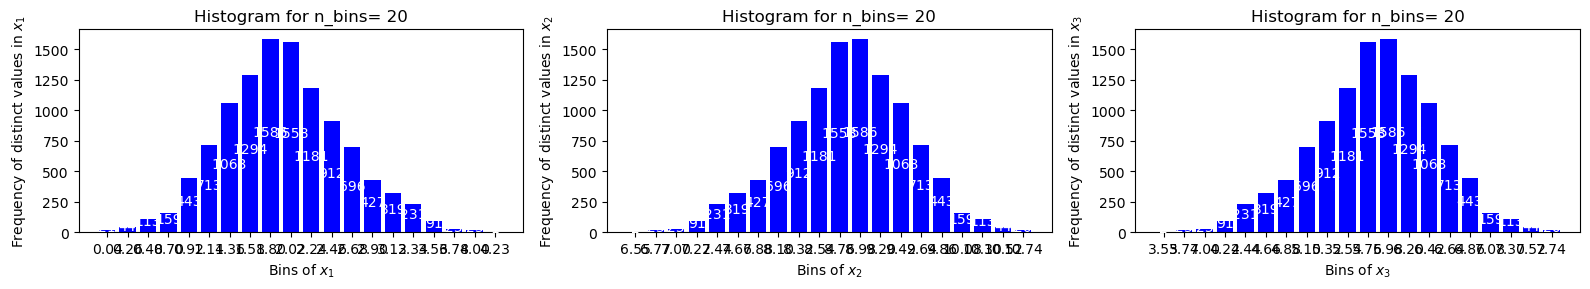

In [185]:
x_hist_bfgs= []
y_hist_bfgs= []

y_part_bfgs= []
x_part_bfgs= []

z_hist_bfgs= []
z_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)


    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)
    
    z_partition_points= partition_interval(z_min, z_max, n_bins)
    z_part_bfgs.append(z_partition_points)
    z_bin_counts = count_values_in_bins(z, z_partition_points)
    z_hist_bfgs.append(z_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 3, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 3, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    
    
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
    
    
    plt.subplot(1, 3, 3)
    bars = plt.bar(range(len(z_bin_counts)), z_bin_counts.values(), align='center', color='blue')
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(z_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(z_bin_counts)), ["{:.2f}".format(b) for b in z_partition_points[:-1]])
    plt.xlabel('Bins of $x_3$')
    plt.ylabel('Frequency of distinct values in $x_3$')
    plt.title('Histogram for n_bins= {}'.format(len(z_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../Merit/solns_runs/Ex5/'+'ex5_gsm_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

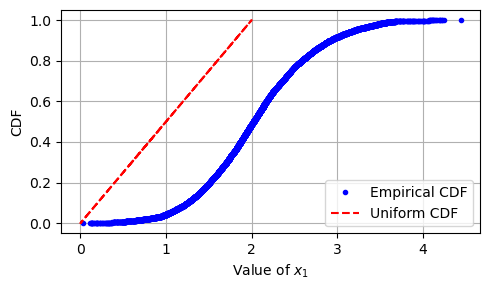

K-S Statistic: 0.957103306620133
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [186]:
# KS Test on x: 
a,b= 0.0,2.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xbfgs))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xbfgs)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xbfgs)
ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex5/ks_ex5_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

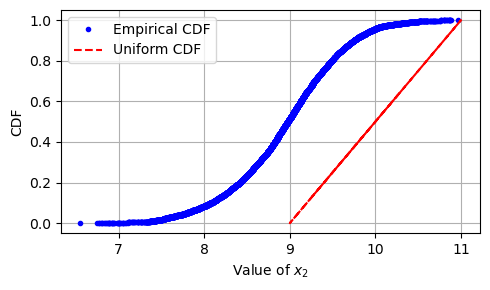

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [187]:
# KS Test on y: 
# Number of samples
a,b= 9.0, 11.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xbfgs))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(xbfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ybfgs)
ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex5/ks_ex5_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ybfgs, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

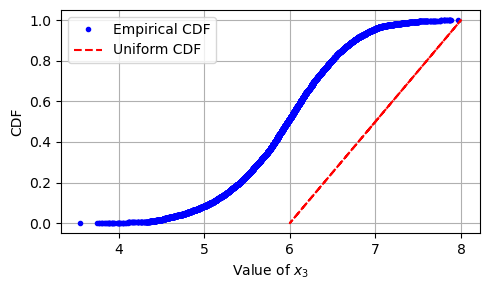

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [188]:
# KS Test on y: 
# Number of samples
a,b= 6.0, 8.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(zbfgs))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(zbfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(zbfgs)
ecdf_bfgs_z = ECDF(zbfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_z.x, ecdf_bfgs_z.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_3$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex5/ks_ex5_x3.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(zbfgs, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


# EIA

## Number of starting points vs. PDP and HD

In [189]:
main_path = "../EIA/solns_runs/Ex5/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../EIA/solns_runs/Ex5/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../EIA/solns_runs/Ex5/N_100/',
 '../EIA/solns_runs/Ex5/N_200/',
 '../EIA/solns_runs/Ex5/N_300/',
 '../EIA/solns_runs/Ex5/N_400/',
 '../EIA/solns_runs/Ex5/N_500/',
 '../EIA/solns_runs/Ex5/N_600/',
 '../EIA/solns_runs/Ex5/N_700/',
 '../EIA/solns_runs/Ex5/N_800/',
 '../EIA/solns_runs/Ex5/N_900/',
 '../EIA/solns_runs/Ex5/N_1000/',
 '../EIA/solns_runs/Ex5/N_1100/',
 '../EIA/solns_runs/Ex5/N_1200/',
 '../EIA/solns_runs/Ex5/N_1300/',
 '../EIA/solns_runs/Ex5/N_1400/',
 '../EIA/solns_runs/Ex5/N_1500/']

In [190]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.0, 2.0, len(distinct_points))

        points = np.column_stack((t_values, 11 - t_values, 8-t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../EIA/solns_runs/Ex5/plot_ex5.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

899 1000
1897 2000
2920 3000
3923 4000
4934 5000
5937 6000
6933 7000
7931 8000
8949 9000
9944 10000
10953 11000
11957 12000
12952 13000
13955 14000
14963 15000


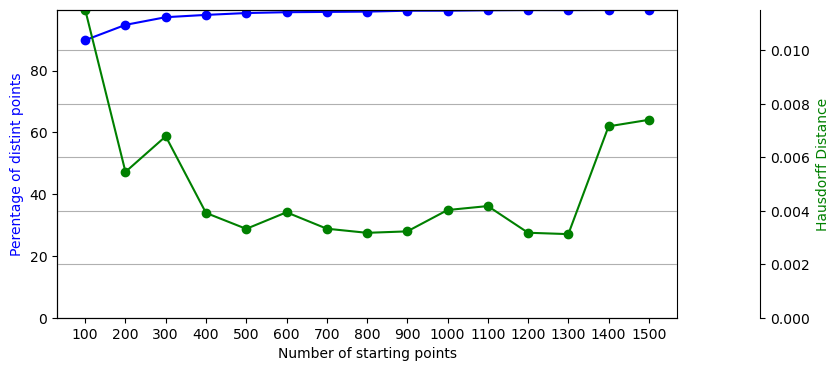

In [191]:
pdpeia, hdeia= get_values(folders)

In [192]:
for (p,h) in zip(pdpeia,hdeia):
    print(p, " * ", h)

89.9  *  0.011518840683063285
94.85  *  0.0054536426990344404
97.33333333333334  *  0.006784178525125329
98.075  *  0.003919245350480109
98.68  *  0.0033234727905708038
98.95  *  0.003943334934266625
99.04285714285714  *  0.00332975462939047
99.1375  *  0.0031751647022520055
99.43333333333332  *  0.00322917114113322
99.44  *  0.004027335018655345
99.57272727272726  *  0.004176065229049655
99.64166666666667  *  0.0031782283613328763
99.63076923076923  *  0.0031266063791579564
99.67857142857143  *  0.007157788996578267
99.75333333333334  *  0.007401336233137694


In [193]:
max(pdpeia), min(hdeia)

(99.75333333333334, 0.0031266063791579564)

In [194]:
#plot_solns(folders)

In [195]:
nubmer_points_list[np.argmax(pdpeia)]

1500

### Histograms

In [196]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpeia)] # 1500
# Best
directory_path = "../EIA/solns_runs/Ex5/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnseia.extend(solns.tolist())

all_solnseia= np.array(all_solnseia)

num, all_solnseia = count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

In [197]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnseia.copy()
x= solns[:,0]

x_min = np.min(x)
x_max = np.max(x)

## y:
y= 11-x
y_min = np.min(y)
y_max = np.max(y)

## z:
z= 8-x
z_min = np.min(z)
z_max = np.max(z)

xeia= x.copy()
yeia= y.copy()
zeia= z.copy()

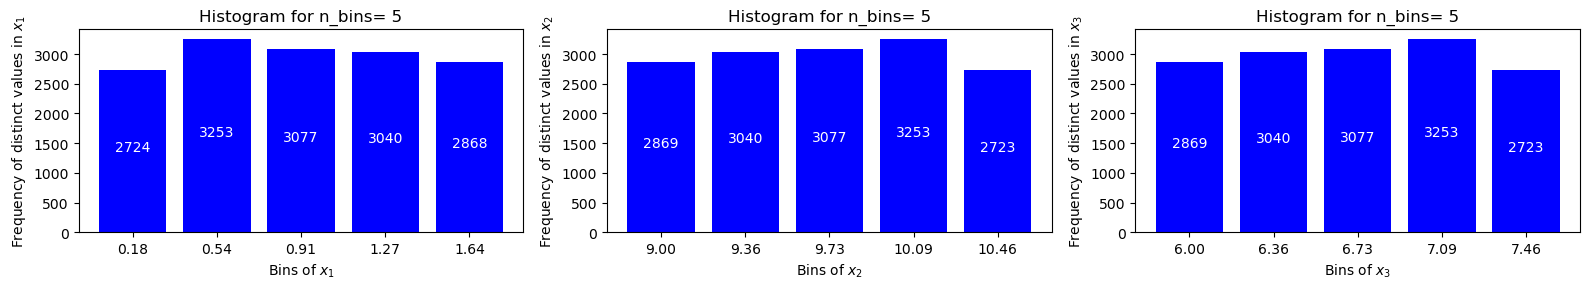

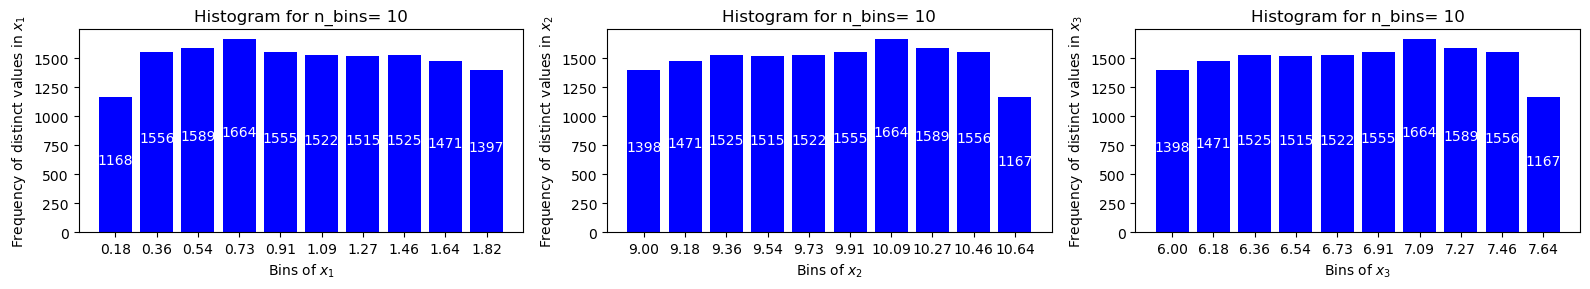

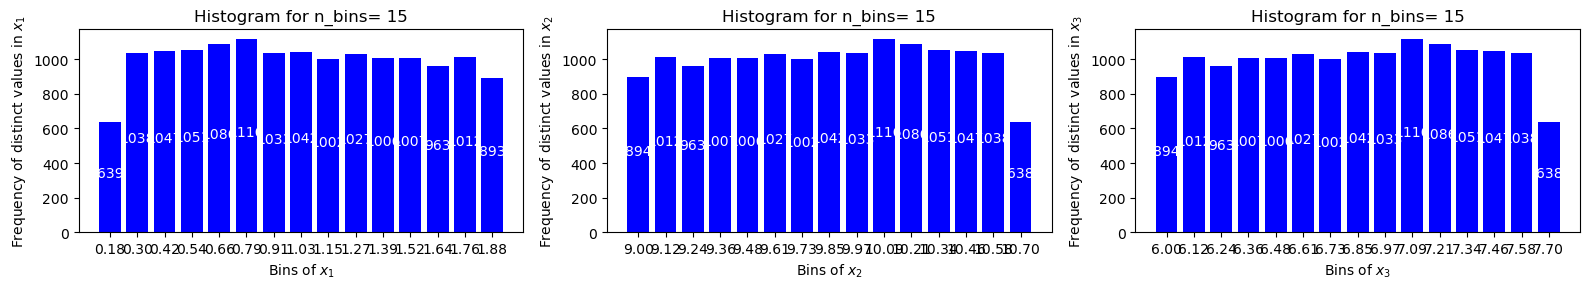

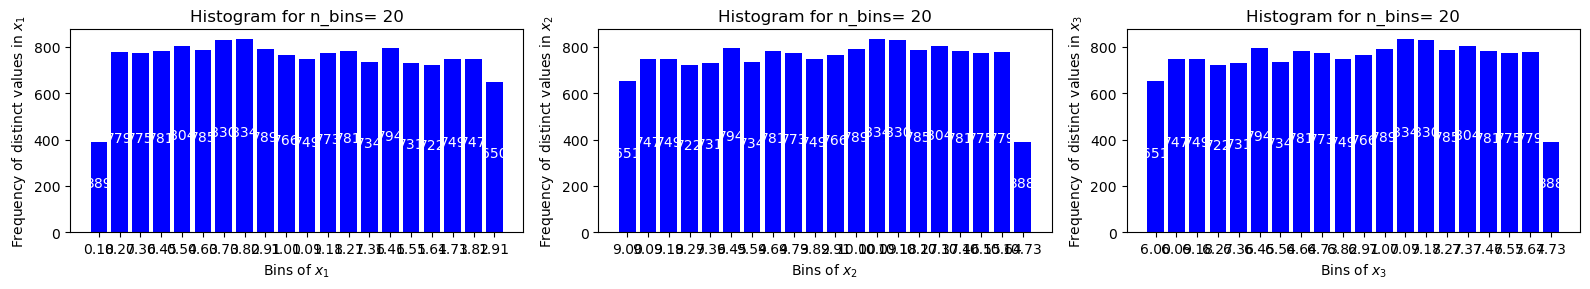

In [198]:
x_hist_eia= []
y_hist_eia= []

y_part_eia= []
x_part_eia= []

z_hist_eia= []
z_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)


    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)
    
    z_partition_points= partition_interval(z_min, z_max, n_bins)
    z_part_eia.append(z_partition_points)
    z_bin_counts = count_values_in_bins(z, z_partition_points)
    z_hist_eia.append(z_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 3, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 3, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    
    
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
    
    
    plt.subplot(1, 3, 3)
    bars = plt.bar(range(len(z_bin_counts)), z_bin_counts.values(), align='center', color='blue')
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(z_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(z_bin_counts)), ["{:.2f}".format(b) for b in z_partition_points[:-1]])
    plt.xlabel('Bins of $x_3$')
    plt.ylabel('Frequency of distinct values in $x_3$')
    plt.title('Histogram for n_bins= {}'.format(len(z_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../EIA/solns_runs/Ex5/'+'ex5_eia_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and  KS-Test

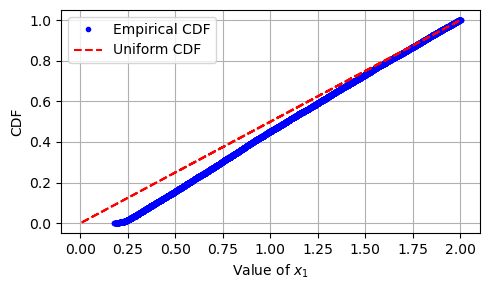

K-S Statistic: 0.5474891131895894
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [199]:
# KS Test on x: 
a,b= 0.0,2.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xeia)
ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex5/ks_ex5_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    

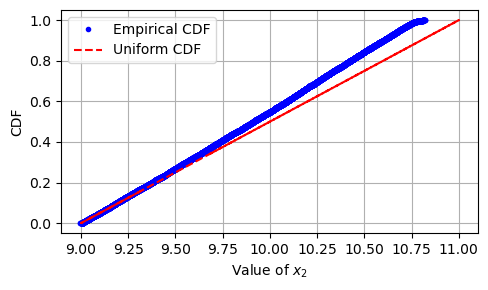

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [200]:
# KS Test on y: 
# Number of samples
a,b= 9.0, 11.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(xeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(yeia)
ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex5/ks_ex5_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(yeia, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [201]:
ks_statistic,p_value

(1.0, 0.0)

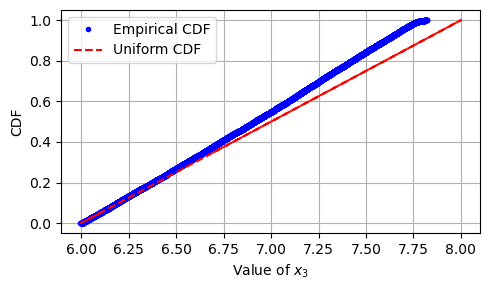

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [202]:
# KS Test on y: 
# Number of samples
a,b= 6.0, 8.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(zeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(zeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(zeia)
ecdf_eia_z = ECDF(zeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_z.x, ecdf_eia_z.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_3$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex5/ks_ex5_x3.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(zeia, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


# SGD (one run with 100 points)

In [203]:
## Number of starting points vs. PDP and HD
folders= ["../SGD/solns_runs/Ex5/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs/Ex5/N_100/',
 '../SGD/solns_runs/Ex5/N_200/',
 '../SGD/solns_runs/Ex5/N_300/',
 '../SGD/solns_runs/Ex5/N_400/',
 '../SGD/solns_runs/Ex5/N_500/',
 '../SGD/solns_runs/Ex5/N_600/',
 '../SGD/solns_runs/Ex5/N_700/',
 '../SGD/solns_runs/Ex5/N_800/',
 '../SGD/solns_runs/Ex5/N_900/',
 '../SGD/solns_runs/Ex5/N_1000/',
 '../SGD/solns_runs/Ex5/N_1100/',
 '../SGD/solns_runs/Ex5/N_1200/',
 '../SGD/solns_runs/Ex5/N_1300/',
 '../SGD/solns_runs/Ex5/N_1400/',
 '../SGD/solns_runs/Ex5/N_1500/']

In [204]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
#             [:,:-1]
            mask= solns[:,-1]<2.5
            solns= solns[mask][:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        res_solns = res_solns[(res_solns[:, 0] >= 0) & (res_solns[:, 1] >= 0)& (res_solns[:, 2] >= 0)]
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:

        t_values = np.random.uniform(0.0, 2.0, len(distinct_points))

        points = np.column_stack((t_values, 11 - t_values, 8-t_values))
        

        
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        print(len(distinct_points), len(res_solns), hausdorff_distance, (len(distinct_points)/(len(res_solns)))*100)
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../SGD/solns_runs/Ex5/plot_ex5.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

217 236 7.99379035584006 91.94915254237289
496 496 8.142076175424414 100.0
726 726 8.25351541477498 100.0
886 886 8.290035314339091 100.0
1140 1140 8.295226641900085 100.0
1377 1377 8.388336229966367 100.0
1606 1606 8.104796397738218 100.0
1861 1861 8.32878151135333 100.0
2125 2125 8.288263836549714 100.0
2396 2396 8.325517939509401 100.0
2615 2615 8.351339700095526 100.0
2833 2833 8.233931549498806 100.0
349 350 8.078943665781921 99.71428571428571
349 350 8.051168851521677 99.71428571428571
349 350 8.066010397078877 99.71428571428571


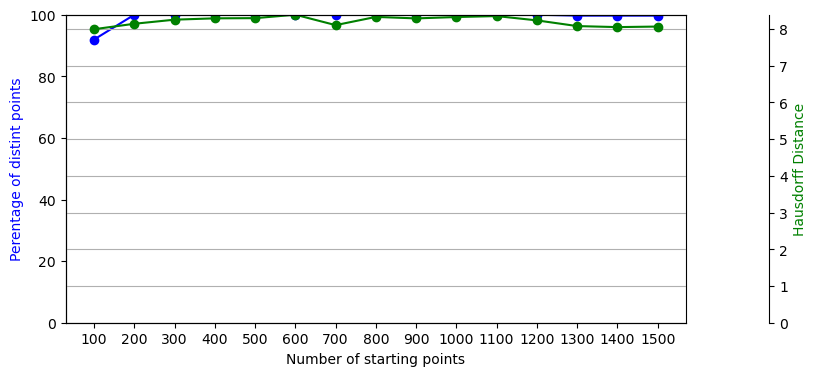

In [205]:
pdpsgd, hdsgd= get_values(folders)

In [206]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

91.94915254237289  *  7.99379035584006
100.0  *  8.142076175424414
100.0  *  8.25351541477498
100.0  *  8.290035314339091
100.0  *  8.295226641900085
100.0  *  8.388336229966367
100.0  *  8.104796397738218
100.0  *  8.32878151135333
100.0  *  8.288263836549714
100.0  *  8.325517939509401
100.0  *  8.351339700095526
100.0  *  8.233931549498806
99.71428571428571  *  8.078943665781921
99.71428571428571  *  8.051168851521677
99.71428571428571  *  8.066010397078877


In [207]:
max(pdpsgd), min(hdsgd)

(100.0, 7.99379035584006)

## Histograms

In [208]:
# SGD
# solnssgd=  np.genfromtxt("../SGD/solns_runs/Ex5"+"/"+"sol5.txt", delimiter=',') #np.array(solns) #sol#np.genfromtxt("../SGD/Ex5"+"/"+"sol5.txt", delimiter=',') #np.array(solns) #sol
# # mask= solnssgd[:,-1]<0.01
# # solnssgd= solnssgd[mask]
# xsgd=solnssgd[:,0]
# n_runs= 50 and 


n_points= nubmer_points_list[np.argmax(pdpsgd)]#1200
# Best
directory_path = "../SGD/solns_runs/Ex5/N_{}".format(n_points)
all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')
    #[:,:-1]
    mask= solns[:,-1]<2.5
    solns= solns[mask][:,:-1]
#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    
    all_solnssgd.extend(solns.tolist())


all_solnssgd= np.array(all_solnssgd)


num, all_solnssgd = count_repeated_points(all_solnssgd)
all_solnssgd= np.array(all_solnssgd)
all_solnssgd = all_solnssgd[(all_solnssgd[:, 0] >= 0) & (all_solnssgd[:, 1] >= 0)& (all_solnssgd[:, 2] >= 0)]
all_solnssgd= np.array(all_solnssgd)
all_solnssgd

array([[4.80171202, 6.63202406, 1.98508702],
       [4.37429553, 7.36980927, 1.86235516],
       [6.05124745, 5.39427057, 0.56804885],
       ...,
       [3.71503437, 6.71783992, 5.18788396],
       [4.34565865, 6.50241945, 3.667876  ],
       [3.2329213 , 8.3840554 , 3.38518931]])

In [209]:
len(all_solnssgd)

496

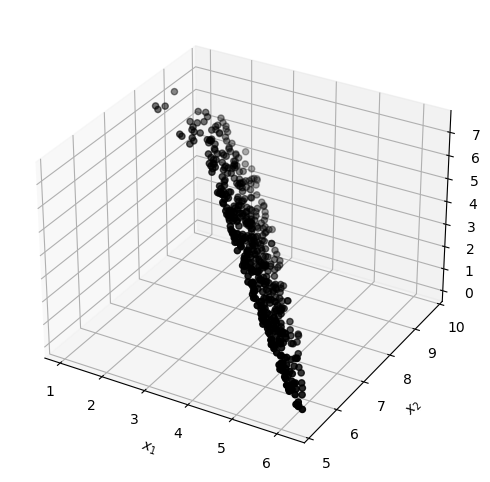

In [210]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_solnssgd[:,0], all_solnssgd[:,1], all_solnssgd[:,2], c= 'black', label= "Solution set")
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_zlabel(r'$x_3$')
plt.show()

In [211]:
len(all_solnssgd)

496

In [212]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnssgd.copy()
x= solns[:,0]

x_min = np.min(x)
x_max = np.max(x)

## y:
y= 11-x
y_min = np.min(y)
y_max = np.max(y)

## z:
z= 8-x
z_min = np.min(z)
z_max = np.max(z)

xsgd= x.copy()
ysgd= y.copy()
zsgd= z.copy()

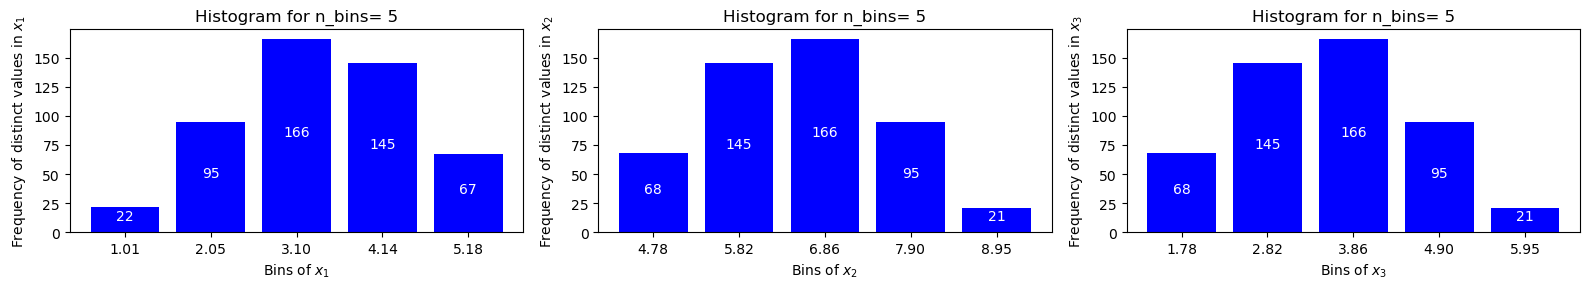

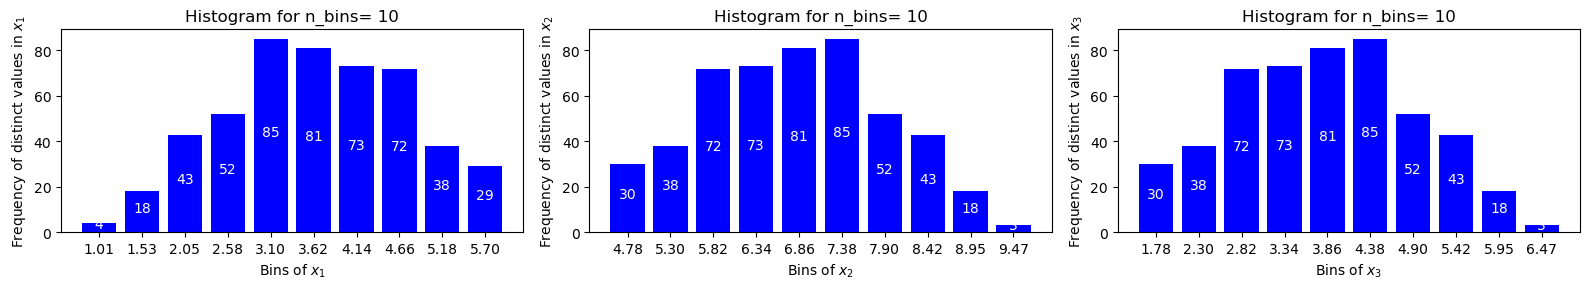

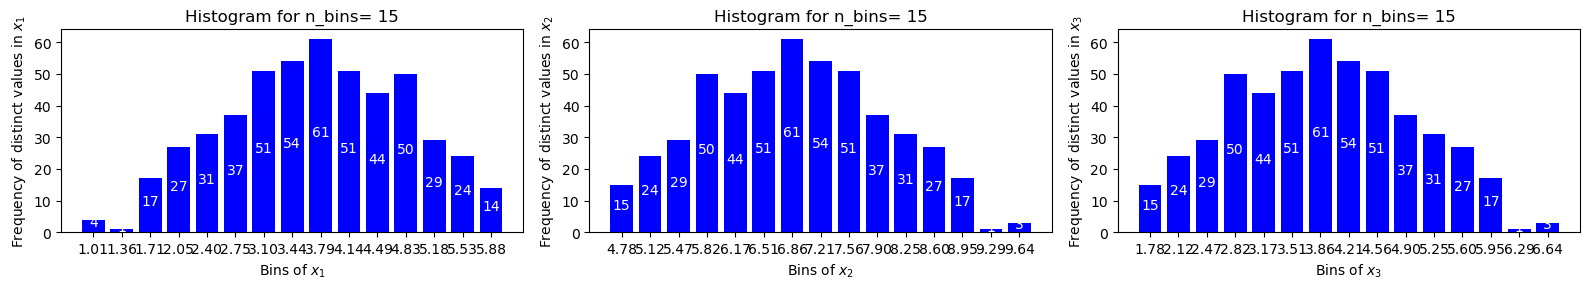

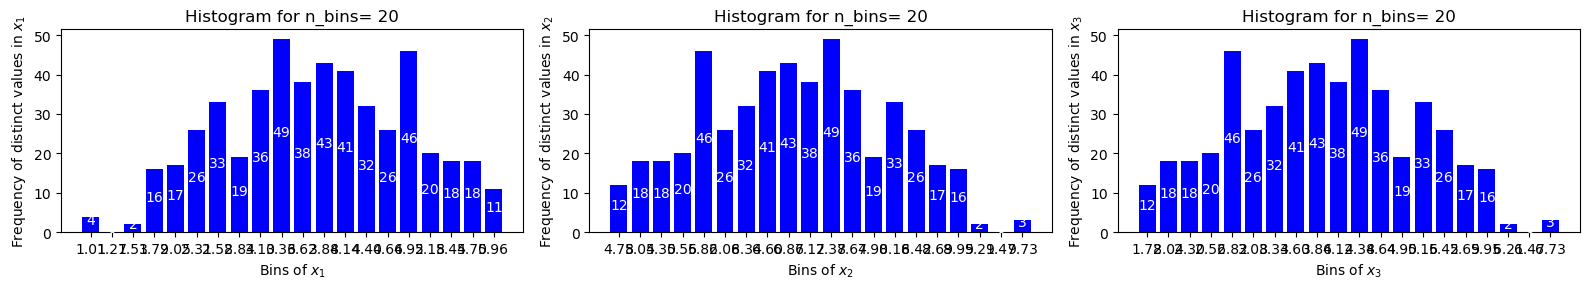

In [213]:
x_hist_sgd= []
y_hist_sgd= []

y_part_sgd= []
x_part_sgd= []

z_hist_sgd= []
z_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)


    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)
    
    z_partition_points= partition_interval(z_min, z_max, n_bins)
    z_part_sgd.append(z_partition_points)
    z_bin_counts = count_values_in_bins(z, z_partition_points)
    z_hist_sgd.append(z_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 3, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 3, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    
    
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
    
    
    plt.subplot(1, 3, 3)
    bars = plt.bar(range(len(z_bin_counts)), z_bin_counts.values(), align='center', color='blue')
    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(z_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(z_bin_counts)), ["{:.2f}".format(b) for b in z_partition_points[:-1]])
    plt.xlabel('Bins of $x_3$')
    plt.ylabel('Frequency of distinct values in $x_3$')
    plt.title('Histogram for n_bins= {}'.format(len(z_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../SGD/solns_runs/Ex5/'+'ex5_eia_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

## K-S Test

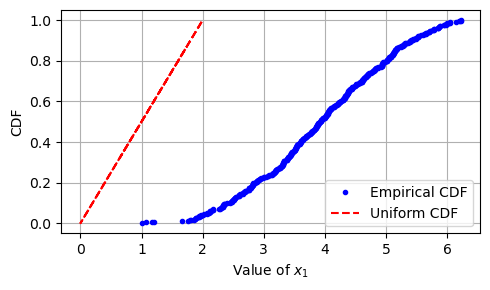

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [214]:
# KS Test on x: 
a,b= 0.0,2.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xsgd)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xsgd)
ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex5/ks_ex5_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    

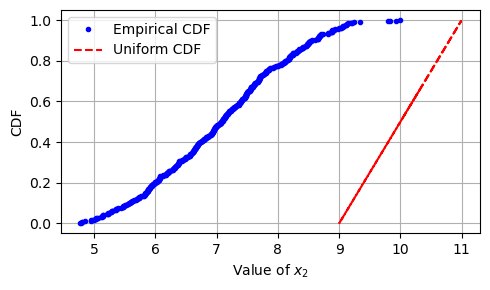

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [215]:
# KS Test on y: 
# Number of samples
a,b= 9.0, 11.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(xsgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ysgd)
ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex5/ks_ex5_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ysgd, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

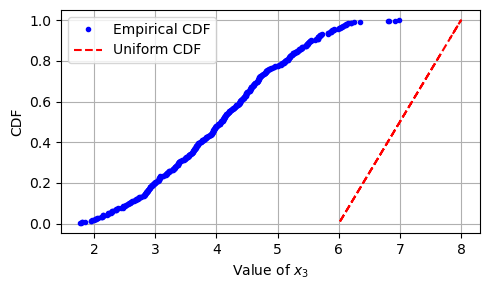

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [216]:
# KS Test on y: 
# Number of samples
a,b= 6.0, 8.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(zsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(zsgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(zsgd)
ecdf_sgd_z = ECDF(zsgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_z.x, ecdf_sgd_z.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_3$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex5/ks_ex5_x3.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(zsgd, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


# KS-Overall

In [217]:
def KS_test(sample, a, b, alpha=0.05):
    ecdf_sgd_x = ECDF(sample)
    x1 = ecdf_sgd_x.x       # First coordinate
    # ecdf_sgd_y = ECDF(ysgd)
    # x2 = ecdf_sgd_y.x   # Second coordinate
    # print("Algorithm ", name)
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")


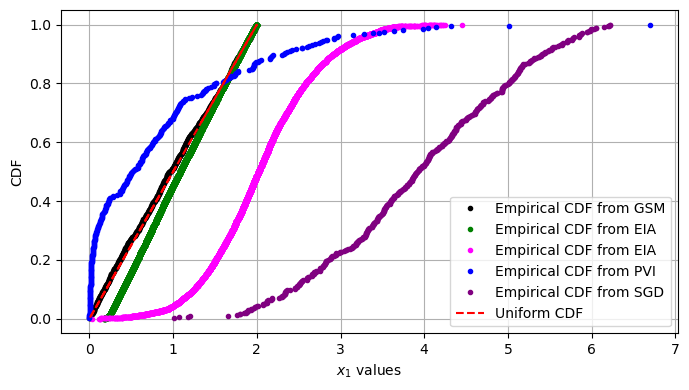

GSM
K-S Statistic: 0.0249
P-Value: 0.7087
Result: Fail to reject H0 → Sample follows Uniform(6.581923194026729e-05,2.000031124063433)

*********
EIA
K-S Statistic: 0.0247
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.17831634575623856,2.0033061055092896)

*********
BFGS
K-S Statistic: 0.2476
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.03591865280684262,4.445733176043793)

*********
PVI
K-S Statistic: 0.5763
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.0,6.692117056485595)

*********
SGD
K-S Statistic: 0.1773
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(1.011345687802157,6.223842812235889)

*********


In [218]:
# KS Test on x: 
a1,b1= 0.0,2.0
uniform_samples = np.random.uniform(low=a1, high=b1, size=len(xeia))
# uniform_samples= np.hstack((uniform_samples,5))
cdf_uniform= [get_cdf_of_uniform(i, a= a1, b= b1) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
# sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex5/all_ks_ex5_x1.png')
plt.show()

# KS_Test(xgsm, algo= "GSM")
# KS_Test(xeia, algo= "EIA")
# KS_Test(xbfgs, algo= "BFGS")
# #KS_Test(data, algo= "PVI")
# #KS_Test(data, algo= "SGD")
print("GSM")
KS_test(xgsm, min(xgsm), max(xgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(xeia, min(xeia), max(xeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(xbfgs, min(xbfgs), max(xbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(xpvi, min(xpvi), max(xpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(xsgd, min(xsgd), max(xsgd), alpha=0.05)
print("*********")

In [219]:
uniform_samples

array([1.33564782, 1.54050114, 1.424432  , ..., 0.91778754, 0.27138733,
       1.0504123 ])

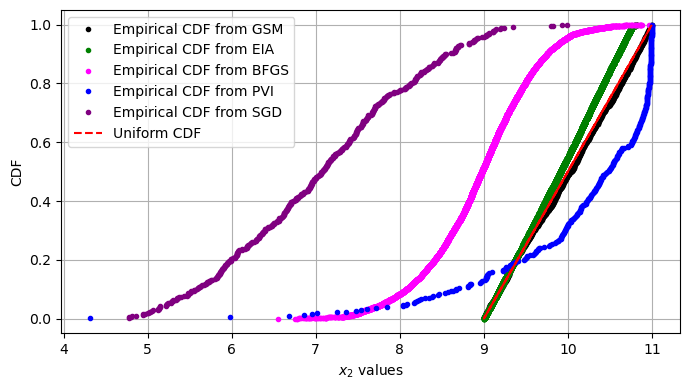

GSM
K-S Statistic: 0.0249
P-Value: 0.7087
Result: Fail to reject H0 → Sample follows Uniform(8.999968875936567,10.99993418076806)

*********
EIA
K-S Statistic: 0.0247
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(8.996693894490711,10.821683654243762)

*********
BFGS
K-S Statistic: 0.2476
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(6.554266823956207,10.964081347193158)

*********
PVI
K-S Statistic: 0.5763
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(4.307882943514405,11.0)

*********
SGD
K-S Statistic: 0.1773
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(4.776157187764111,9.988654312197843)

*********


In [220]:
# KS Test on y: 
# Number of samples
a,b= 9.0,11.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(yeia))
uniform_samples= np.hstack((uniform_samples,9))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
# sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex5/all_ks_ex5_x2.png')
plt.show()


    
print("GSM")
KS_test(ygsm, min(ygsm), max(ygsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(yeia, min(yeia), max(yeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(ybfgs, min(ybfgs), max(ybfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(ypvi, min(ypvi), max(ypvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(ysgd, min(ysgd), max(ysgd), alpha=0.05)
print("*********")

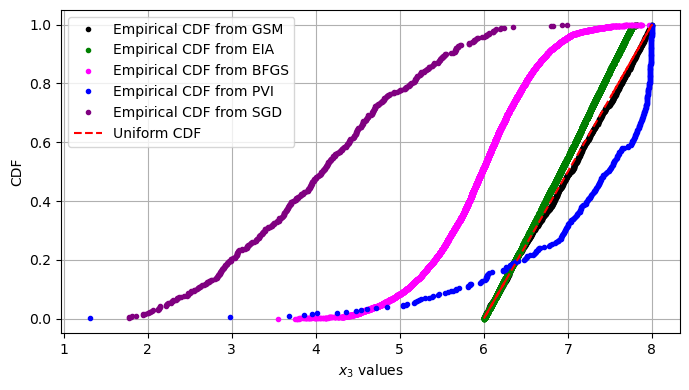

GSM
K-S Statistic: 0.0249
P-Value: 0.7087
Result: Fail to reject H0 → Sample follows Uniform(5.999968875936567,7.99993418076806)

*********
EIA
K-S Statistic: 0.0247
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(5.99669389449071,7.8216836542437616)

*********
BFGS
K-S Statistic: 0.2476
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(3.5542668239562074,7.964081347193157)

*********
PVI
K-S Statistic: 0.5763
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(1.3078829435144046,8.0)

*********
SGD
K-S Statistic: 0.1773
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(1.7761571877641114,6.988654312197843)

*********


In [221]:
# KS Test on y: 
# Number of samples
a,b= 6.0,8.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(zeia))
# uniform_samples= np.hstack((uniform_samples,9))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
# n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
# sorted_samples = np.sort(y)
ecdfgsm= ECDF(zgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(zeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(zbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(zpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(zsgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_3$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex5/all_ks_ex5_x3.png')
plt.show()


    
print("GSM")
KS_test(zgsm, min(zgsm), max(zgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(zeia, min(zeia), max(zeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(zbfgs, min(zbfgs), max(zbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(zpvi, min(zpvi), max(zpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(zsgd, min(zsgd), max(zsgd), alpha=0.05)
print("*********")

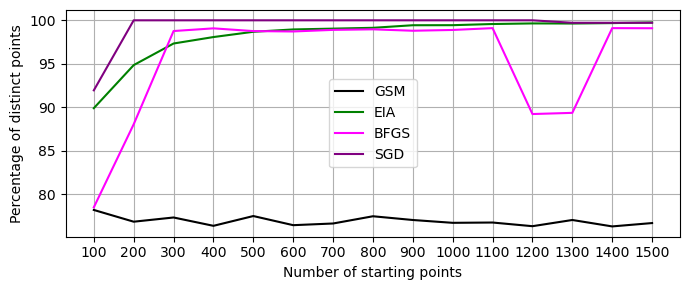

In [222]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex5/ex5_npoints_pdp.png')
plt.show()

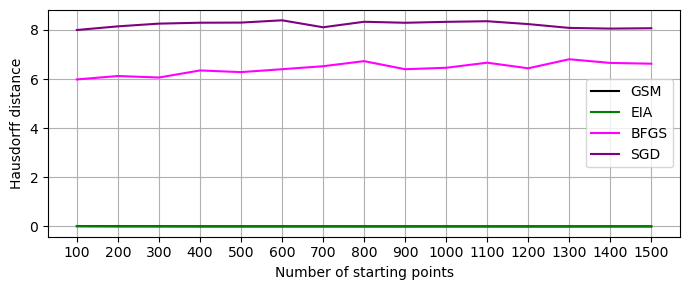

In [223]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex5/ex5_npoints_hd.png')
plt.show()

In [224]:
# hdgsm,hdeia

# Histograms

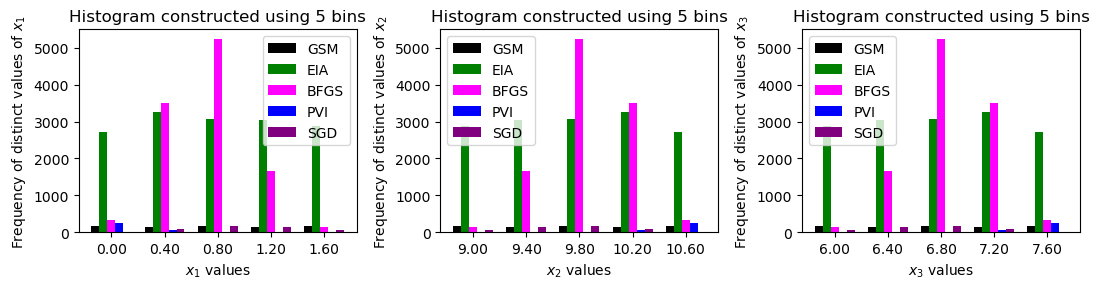

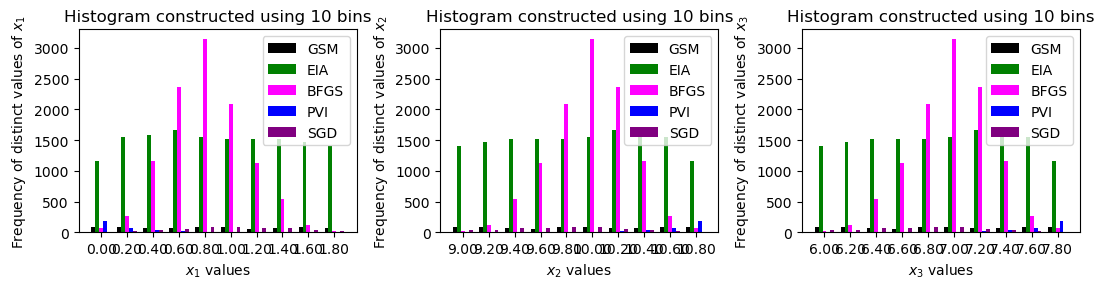

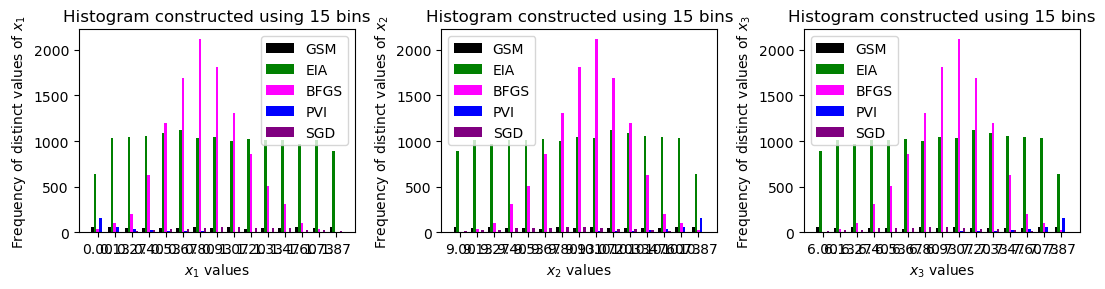

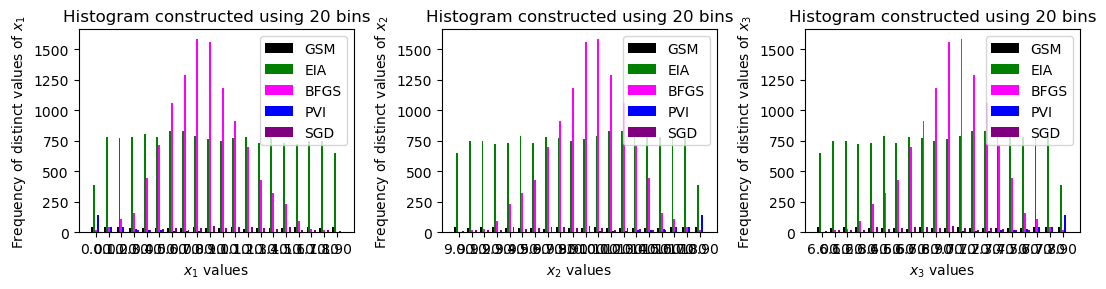

In [225]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 3, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_1$ values')
    plt.ylabel('Frequency of distinct values of $x_1$')
    plt.title('Histogram constructed using {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(x_hist_gsm[n_bins])))
    #plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 3, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_2$ values')
    plt.ylabel('Frequency of distinct values of $x_2$')
    #plt.title('Histogram for n_bins= {}'.format(len(y_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
    plt.title('Histogram constructed using {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    
    
    plt.subplot(1, 3, 3)
    
    z = np.arange(len(z_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(z - 2*width, list(z_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(z - width, list(z_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(z, list(z_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(z + width, list(z_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(z + 2*width, list(z_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in z_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_3$ values')
    plt.ylabel('Frequency of distinct values of $x_3$')
    plt.title('Histogram constructed using {} bins'.format(len(z_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(z_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex5/'+'ex5_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


In [226]:
Ex5Sols= {
        "EIA":
                {
                    "hd": None, "pdp": None, "solutions": None
                },

     "SGD":{
        "hd":None, "pdp": None, "solutions":None
    },

     "GSM":{
        "hd":None, "pdp": None, "solutions":None
    },

     "PVI":{
        "hd":None, "pdp": None, "solutions":None
    },

     "BFGS":{
        "hd":None, "pdp": None, "solutions":None
    }



}

Algorithms= ["EIA", "SGD", "GSM", "PVI", "BFGS"]

HDResults= [hdeia, hdsgd, hdgsm, hdgpvi, hdbfgs]
PDPResults= [pdpeia, pdpsgd, pdpgsm, pdppvi, pdpbfgs]
# dataSol= [data_eia, data_sgd, data_gsm, data_pvi, data_bfgs]

for (idx, algo) in enumerate(Algorithms):

    Ex5Sols[algo]["hd"]= HDResults[idx]
    Ex5Sols[algo]["pdp"]= PDPResults[idx]
    # Ex4Sols[algo]["solutions"]= dataSol[idx]


import json

def convert_ndarray(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("Ex5Sols.json", "w", encoding="utf-8") as f:
    json.dump(Ex5Sols, f, indent=4, default=convert_ndarray)


import json

with open("Ex5Sols.json", "r", encoding="utf-8") as f:
    Ex5Sols_loaded = json.load(f)

